# Clustering Analysis: Gut Microbiome Population Identification

- **Objective:** Perform clustering on microbiome data to uncover patterns that distinguish rural and urban populations in Mexico.

- **Data Summary:**
    - Samples: 208 (123 rural, 85 urban)  
    - Features:  
      - 13,529 OTUs (taxonomic diversity)  
      - 532 functional pathways (biochemical processes)  

- **Goal:** Identify and characterize meaningful clusters to explore population-specific microbiome traits.


## Data Loading and Preprocessing

This section focuses on preparing the microbiome dataset for clustering analysis

First we need to import the neccesary libraries for the analysis

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = '1'

In [2]:
import sys
sys.path.append("../")
from custom_clustering import CustomClustering

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score
from yellowbrick.cluster import SilhouetteVisualizer
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics.cluster import homogeneity_score
import numpy as np
import optuna

Now we read the taxonomy and functional datasets, as well as the metadata that we are going to need later

In [5]:
def read_data():
    metadata = pd.read_excel('../datasets/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')
    taxonomy = pd.read_csv('../datasets/bracken_taxonomy.csv', index_col = 0)
    taxonomy = taxonomy.T
    pathways_unstratified = pd.read_csv('../datasets/latinbiota_pathabundance_unstratified.tsv', sep = '\t', index_col = 0)
    pathways_unstratified = pathways_unstratified[[x for x in pathways_unstratified.columns if '.1' not in x]]
    pathways_unstratified.drop('UNMAPPED', axis = 0, inplace = True)
    pathways_unstratified.drop('UNINTEGRATED', axis = 0, inplace = True)
    pathways_unstratified = pathways_unstratified.T
    pathways_unstratified.index = [x.replace('_paired_Abundance', '') for x in pathways_unstratified.index]
    
    return metadata, taxonomy, pathways_unstratified

In [6]:
metadata, taxonomy, pathways = read_data()

After reading the data we are going to drop some samples which were detected to be from a very bad quality

In [7]:
sample_outliers = ['37082_3#16','37082_2#4','37035_2#22','37035_7#18','36703_3#20','36703_3#4']

taxonomy.drop(sample_outliers, axis = 0, inplace = True)
pathways.drop(sample_outliers, axis = 0, inplace = True)

Finally we are going to define a list that saves the label of each sample (Urban/Rural)

In [8]:
lifestyle = []
for sample in taxonomy.index:
    lifestyle.append(metadata[metadata['Lane'] == sample]['Lifestyle'].iloc[0])

## Model Setup

In this section, we define and configure the custom clustering models to analyze the microbiome data. The steps include:

1. **Model Selection**: Choosing appropriate clustering algorithms (e.g., k-means, hierarchical clustering, DBSCAN) based on the data's characteristics.
2. **Hyperparameter Tuning**: Setting key parameters such as the number of clusters or distance metrics to optimize model performance.
3. **Implementation**: Applying the chosen models to the preprocessed data.
4. **Evaluation**: Assessing clustering results using metrics like silhouette scores and visualizing clusters for interpretability.

The objective is to form meaningful clusters that align with the biological and demographic context of the data.


### Hyper parameter tunning

In [42]:
def objective(trial):
    algorithm = trial.suggest_categorical('algorithm', ['kmeans'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['presence'])
    filter_threshold = trial.suggest_int('filter_threshold', 0, 120, step=5)
    k = trial.suggest_int('k', 2, 10)

    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        n_clusters=k
    )

    
    scores = cross_val_score(
        model, taxonomy, lifestyle, cv=StratifiedKFold(n_splits=5), scoring='homogeneity_score', error_score='raise'
    )

    return scores.mean()

# kmeans_study = optuna.create_study(direction='maximize')

# kmeans_study.optimize(objective, n_trials=1000)

# kmeans_study.trials_dataframe().to_csv('kmeans_presence_results.csv', index = False)

print("Best Parameters:", kmeans_study.best_params)
print("Best Score:", kmeans_study.best_value)

[I 2024-12-19 23:36:10,858] A new study created in memory with name: no-name-4f91bb1d-c6ce-4e57-8c27-4d9eede1c415
[I 2024-12-19 23:36:12,079] Trial 0 finished with value: 0.204594181122969 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'presence', 'filter_threshold': 15, 'k': 7}. Best is trial 0 with value: 0.204594181122969.
[I 2024-12-19 23:36:13,415] Trial 1 finished with value: 0.22792390970057091 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'presence', 'filter_threshold': 70, 'k': 3}. Best is trial 1 with value: 0.22792390970057091.
[I 2024-12-19 23:36:14,427] Trial 2 finished with value: 0.27481568033670833 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'presence', 'filter_threshold': 90, 'k': 7}. Best is trial 2 with value: 0.27481568033670833.
[I 2024-12-19 23:36:15,505] Trial 3 finished with value: 0.214176589691637 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'presence', 'filter_threshold': 30, 'k': 9}. Best is trial 2 with 

Best Parameters: {'algorithm': 'kmeans', 'filter_criteria': 'presence', 'filter_threshold': 115, 'k': 8}
Best Score: 0.40330328255103787


In [43]:
def objective(trial):
    algorithm = trial.suggest_categorical('algorithm', ['kmeans'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['abundance'])
    filter_threshold = trial.suggest_float('filter_threshold', 0, 2.5, step=0.1)
    k = trial.suggest_int('k', 2, 10)
    
    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        n_clusters=k
    )

    
    scores = cross_val_score(
        model, taxonomy, lifestyle, cv=StratifiedKFold(n_splits=5), scoring='homogeneity_score', error_score='raise'
    )

    return scores.mean()

kmeans_study2 = optuna.create_study(direction='maximize')


kmeans_study2.optimize(objective, n_trials=1000) 

kmeans_study2.trials_dataframe().to_csv('kmeans_abundance_results.csv', index = False)

print("Best Parameters:", kmeans_study2.best_params)
print("Best Score:", kmeans_study2.best_value)

[I 2024-12-20 00:36:35,288] A new study created in memory with name: no-name-2bcf3eb3-9e47-4724-91a8-0e036a43833b
[I 2024-12-20 00:36:35,473] Trial 0 finished with value: 0.6190543967474512 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'abundance', 'filter_threshold': 1.8, 'k': 3}. Best is trial 0 with value: 0.6190543967474512.
[I 2024-12-20 00:36:35,680] Trial 1 finished with value: 0.5890266779845893 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'abundance', 'filter_threshold': 0.30000000000000004, 'k': 5}. Best is trial 0 with value: 0.6190543967474512.
[I 2024-12-20 00:36:35,861] Trial 2 finished with value: 0.6366141013345186 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'abundance', 'filter_threshold': 1.0, 'k': 2}. Best is trial 2 with value: 0.6366141013345186.
[I 2024-12-20 00:36:36,027] Trial 3 finished with value: 0.564916128031536 and parameters: {'algorithm': 'kmeans', 'filter_criteria': 'abundance', 'filter_threshold': 2.0, 'k': 7}.

Best Parameters: {'algorithm': 'kmeans', 'filter_criteria': 'abundance', 'filter_threshold': 1.5, 'k': 5}
Best Score: 0.7713320968351981


In [20]:
model = CustomClustering(
        algorithm='gaussian_mixture',
        filter_criteria='presence',
        filter_threshold=80,
        n_components=10
    )

In [21]:
model.fit(taxonomy)

CustomClustering(algorithm='gaussian_mixture', filter_threshold=80)

In [22]:
model.predict(taxonomy)

array([3, 8, 3, 0, 1, 4, 3, 0, 2, 1, 6, 3, 2, 1, 3, 3, 0, 0, 8, 2, 2, 0,
       3, 1, 6, 3, 0, 0, 0, 3, 0, 8, 8, 8, 0, 0, 3, 0, 6, 2, 3, 2, 3, 3,
       8, 2, 0, 3, 0, 8, 3, 3, 0, 2, 0, 8, 8, 1, 0, 8, 0, 0, 0, 3, 0, 2,
       3, 3, 0, 3, 0, 3, 0, 0, 3, 7, 8, 6, 0, 8, 3, 3, 4, 6, 0, 0, 1, 3,
       3, 6, 0, 8, 8, 3, 1, 3, 3, 8, 1, 3, 0, 1, 0, 1, 2, 8, 3, 1, 2, 0,
       8, 0, 1, 4, 5, 2, 0, 3, 2, 0, 3, 3, 0, 0, 3, 0, 3, 0, 0, 2, 0, 1,
       0, 0, 9, 4, 3, 0, 1, 2, 3, 0, 0, 3, 3, 8, 3, 8, 1, 3, 5, 3, 0, 4,
       3, 4, 1, 3, 3, 8, 3, 0, 2, 0, 3, 3, 0, 0, 3, 3, 8, 8, 3, 8, 3, 3,
       7, 0, 8, 9, 0, 1, 3, 1, 0, 0, 0, 8, 9, 0, 2, 0, 8, 1, 3, 3, 3, 3,
       3])

In [24]:
homogeneity_score(lifestyle, model.predict(taxonomy))

np.float64(0.25413227389936544)

In [9]:
def objective(trial):
    algorithm = trial.suggest_categorical('algorithm', ['gaussian_mixture'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['presence'])
    filter_threshold = trial.suggest_int('filter_threshold', 60, 120, step=5)
    k = trial.suggest_int('k', 8, 10)
    
    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        n_components=k,
        covariance_type='diag',
    )

    print(model.kwargs)
    
    scores = cross_val_score(
        model, taxonomy, lifestyle, cv=StratifiedKFold(n_splits=3), scoring='homogeneity_score', error_score='raise', n_jobs=2
    )
    print(scores)

    return scores.mean()

gmm_study = optuna.create_study(direction='maximize')

gmm_study.optimize(objective, n_trials=3)

# gmm_study.trials_dataframe().to_csv('gmm_presence_results.csv', index = False)

print("Best Parameters:", gmm_study.best_params)
print("Best Score:", gmm_study.best_value)

[I 2025-01-06 11:55:04,030] A new study created in memory with name: no-name-c182b0b8-7d8e-44c7-8026-ec372049dd7d


{'n_components': 10, 'covariance_type': 'diag'}


[I 2025-01-06 11:55:46,419] Trial 0 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 115, 'k': 10}. Best is trial 0 with value: 0.0.


[0. 0. 0.]
{'n_components': 10, 'covariance_type': 'diag'}


[I 2025-01-06 11:56:49,137] Trial 1 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 95, 'k': 10}. Best is trial 0 with value: 0.0.


[0. 0. 0.]
{'n_components': 8, 'covariance_type': 'diag'}


[I 2025-01-06 11:57:59,991] Trial 2 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 90, 'k': 8}. Best is trial 0 with value: 0.0.


[0. 0. 0.]
Best Parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 115, 'k': 10}
Best Score: 0.0


In [37]:
def objective(trial):
    # Hyperparameter suggestions
    algorithm = trial.suggest_categorical('algorithm', ['gaussian_mixture'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['presence'])
    filter_threshold = trial.suggest_int('filter_threshold', 0, 120, step=5)
    k = trial.suggest_int('k', 2, 10)

    # Initialize the clustering model
    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        n_components=k,
        covariance_type='diag',
    )
    

    # Prepare Stratified K-Fold
    skf = StratifiedKFold(n_splits=3)

    # Store scores for each fold
    scores = []

    # Manual Stratified K-Fold
    for train_index, test_index in skf.split(taxonomy, lifestyle):
        # Handle indexing for taxonomy (DataFrame) and lifestyle (list)
        X_train, X_test = taxonomy.iloc[train_index], taxonomy.iloc[test_index]
        y_train = [lifestyle[i] for i in train_index]
        y_test = [lifestyle[i] for i in test_index]
        
        # Fit the model on training data
        model.fit(X_train, y_train)
        
        # Predict clusters on test data
        y_pred = model.predict(X_test)

        # Compute homogeneity score
        score = homogeneity_score(y_test, y_pred)
        scores.append(score)

    # Return the mean score across all folds
    mean_score = sum(scores) / len(scores)
    print(scores)

    return mean_score

gmm_study = optuna.create_study(direction='maximize')

gmm_study.optimize(objective, n_trials=3)

# gmm_study.trials_dataframe().to_csv('gmm_presence_results.csv', index = False)

print("Best Parameters:", gmm_study.best_params)
print("Best Score:", gmm_study.best_value)

[I 2025-01-04 15:18:08,267] A new study created in memory with name: no-name-824e1ccd-96e8-4499-8f32-c0581503cc15
[I 2025-01-04 15:18:09,037] Trial 0 finished with value: 0.17063012029784427 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 80, 'k': 10}. Best is trial 0 with value: 0.17063012029784427.


[np.float64(0.162376439999259), np.float64(0.13661354382098692), np.float64(0.21290037707328688)]


[I 2025-01-04 15:18:09,876] Trial 1 finished with value: 0.18384009155713166 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 50, 'k': 6}. Best is trial 1 with value: 0.18384009155713166.


[np.float64(0.08465030282898386), np.float64(0.25412984860318083), np.float64(0.21274012323923033)]


[I 2025-01-04 15:18:10,664] Trial 2 finished with value: 0.1073790871250147 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 80, 'k': 6}. Best is trial 1 with value: 0.18384009155713166.


[np.float64(0.057002723357830444), np.float64(0.07147558595508534), np.float64(0.19365895206212833)]
Best Parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'presence', 'filter_threshold': 50, 'k': 6}
Best Score: 0.18384009155713166


In [13]:
def objective(trial):
    # Suggest values for each hyperparameter
    algorithm = trial.suggest_categorical('algorithm', ['gaussian_mixture'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['abundance'])
    filter_threshold = trial.suggest_float('filter_threshold', 0, 2.5, step=0.1)
    k = trial.suggest_int('k', 2, 10)
    
    # Initialize your custom clustering model with suggested hyperparameters
    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        n_components=k
    )

    
    # Perform cross-validation with the custom scoring function
    scores = cross_val_score(
        model, taxonomy, lifestyle, cv=StratifiedKFold(n_splits=3), scoring='homogeneity_score', error_score='raise',n_jobs=3
    )

    return scores.mean()

# Create an Optuna study
gmm_study2 = optuna.create_study(direction='maximize')  # Maximize the homogeneity score

# Run the optimization process
gmm_study2.optimize(objective, n_trials=10)  # Perform 50 trials

# gmm_study2.trials_dataframe().to_csv('gmm_abundance_results.csv', index = False)

# Print the best parameters and score
print("Best Parameters:", gmm_study2.best_params)
print("Best Score:", gmm_study2.best_value)

[I 2025-01-03 15:02:38,970] A new study created in memory with name: no-name-ef8369aa-636c-41dd-9a68-55b4fd4befb2
[I 2025-01-03 15:02:39,204] Trial 0 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'abundance', 'filter_threshold': 2.1, 'k': 5}. Best is trial 0 with value: 0.0.
[I 2025-01-03 15:02:39,404] Trial 1 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'abundance', 'filter_threshold': 2.5, 'k': 6}. Best is trial 0 with value: 0.0.
[I 2025-01-03 15:02:39,656] Trial 2 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'abundance', 'filter_threshold': 0.6000000000000001, 'k': 4}. Best is trial 0 with value: 0.0.
[I 2025-01-03 15:02:39,868] Trial 3 finished with value: 0.0 and parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'abundance', 'filter_threshold': 2.1, 'k': 4}. Best is trial 0 with value: 0.0.
[I 2025-01-03 15:02:40,119] Tri

Best Parameters: {'algorithm': 'gaussian_mixture', 'filter_criteria': 'abundance', 'filter_threshold': 2.1, 'k': 5}
Best Score: 0.0


In [34]:
def objective(trial):
    # Suggest values for each hyperparameter
    algorithm = trial.suggest_categorical('algorithm', ['hdbscan'])
    filter_criteria = trial.suggest_categorical('filter_criteria', ['abundance'])
    filter_threshold = trial.suggest_float('filter_threshold', 0, 2.5, step=0.1)
    k = trial.suggest_int('k', 2, 10)
    
    # Initialize your custom clustering model with suggested hyperparameters
    model = CustomClustering(
        algorithm=algorithm,
        filter_criteria=filter_criteria,
        filter_threshold=filter_threshold,
        k=k
    )

    
    # Perform cross-validation with the custom scoring function
    scores = cross_val_score(
        model, taxonomy, lifestyle, cv=StratifiedKFold(n_splits=3), scoring='homogeneity_score', error_score='raise'
    )

    return scores.mean()

# Create an Optuna study
hdbscan_study = optuna.create_study(direction='maximize')  # Maximize the homogeneity score

# Run the optimization process
hdbscan_study.optimize(objective, n_trials=5)  # Perform 50 trials

hdbscan_study.trials_dataframe().to_csv('hdbscan_study_abundance_results.csv', index = False)

# Print the best parameters and score
print("Best Parameters:", hdbscan_study_study.best_params)
print("Best Score:", hdbscan_study_study.best_value)

[I 2024-12-18 22:47:22,589] A new study created in memory with name: no-name-2c9b1ad8-a813-49a0-80fb-4da4d7b8f48d
[W 2024-12-18 22:47:22,642] Trial 0 failed with parameters: {'algorithm': 'hdbscan', 'filter_criteria': 'abundance', 'filter_threshold': 2.5, 'k': 3} because of the following error: AttributeError("'HDBSCAN' object has no attribute 'predict'").
Traceback (most recent call last):
  File "/home/rafa/.conda/envs/clustering-env/lib/python3.11/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2860849/106165024.py", line 18, in objective
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "/home/rafa/.conda/envs/clustering-env/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/rafa/.conda/envs/clustering-env/lib/python3.11/site-packages/sklearn/m

AttributeError: 'HDBSCAN' object has no attribute 'predict'

## Comparison of Algorithms

Initialized clustom clustering models with the best performing parameters and predicting the labels on the complete dataset

In [44]:
clustering1 = CustomClustering(filter_criteria = 'abundance', filter_threshold=1.5, n_clusters = 5, random_state=42)
clustering2 = CustomClustering(filter_threshold=115, n_clusters = 8, random_state=42)
clustering3 = CustomClustering(algorithm = 'gaussian_mixture', filter_criteria = 'abundance', filter_threshold=1.5, n_components = 5, random_state=42)
clustering4 = CustomClustering(algorithm = 'gaussian_mixture', filter_threshold=115, n_components = 8, random_state=42)

In [45]:
clustering1.fit(taxonomy)
clustering2.fit(taxonomy)
clustering3.fit(taxonomy)
clustering4.fit(taxonomy)

CustomClustering(algorithm='gaussian_mixture', filter_threshold=115)

In [46]:
clusters1 = clustering1.predict(taxonomy)
clusters2 = clustering2.predict(taxonomy)
clusters3 = clustering3.predict(taxonomy)
clusters4 = clustering4.predict(taxonomy)

Calculate clustering metrics of the models

In [47]:
def get_clustering_metrics(data, model, cluster_labels, true_labels):
    """
    Compute clustering evaluation metrics for the provided data and cluster assignments.

    Args:
        data (pd.DataFrame): A DataFrame of shape (n_samples, n_features) with the input data.
        model (object): A fitted clustering model that has a `selected_features_` attribute 
                        containing the indices of the selected features.
        cluster_labels (np.ndarray): A 1D array of shape (n_samples,) with the predicted cluster labels.
        true_labels (np.ndarray): A 1D array of shape (n_samples,) with the true labels of the data.

    Returns:
        Tuple[float, float, float, float]: A tuple containing:
            - Silhouette score (float): Measures how similar each sample is to its own cluster compared to other clusters.
            - Davies-Bouldin score (float): Measures the average similarity ratio of each cluster with other clusters.
            - Calinski-Harabasz score (float): Measures the ratio of the sum of between-cluster dispersion and within-cluster dispersion.
            - Homogeneity score (float): Measures the extent to which clusters contain only members of a single class.
    """
    scaler = StandardScaler()
    data = data[model.selected_features_]
    data = scaler.fit_transform(data)
    print(f'Silhoutte score: {silhouette_score(data, cluster_labels)}')
    print(f'Davies-Bouldin score: {davies_bouldin_score(data, cluster_labels)}')
    print(f'Calinksi-Harabasz score: {calinski_harabasz_score(data, cluster_labels)}')
    print(f'Homogenity score: {homogeneity_score(true_labels, cluster_labels)}')

    return silhouette_score(data, cluster_labels), davies_bouldin_score(data, cluster_labels), calinski_harabasz_score(data, cluster_labels), homogeneity_score(true_labels, cluster_labels)

In [48]:
silhouette1, davies1, calinski1, homogeneity1 = get_clustering_metrics(taxonomy, clustering1, clusters1, lifestyle)

Silhoutte score: 0.042682580562952946
Davies-Bouldin score: 2.92690255858997
Calinksi-Harabasz score: 11.883243678859918
Homogenity score: 0.5300709604707519


In [49]:
silhouette2, davies2, calinski2, homogeneity2 = get_clustering_metrics(taxonomy, clustering2, clusters2, lifestyle)

Silhoutte score: 0.0713513310013746
Davies-Bouldin score: 2.343161935909547
Calinksi-Harabasz score: 15.706977706765736
Homogenity score: 0.1840515120835955


In [50]:
silhouette3, davies3, calinski3, homogeneity3 = get_clustering_metrics(taxonomy, clustering3, clusters3, lifestyle)

Silhoutte score: 0.042682580562952946
Davies-Bouldin score: 2.92690255858997
Calinksi-Harabasz score: 11.883243678859918
Homogenity score: 0.5300709604707519


In [51]:
silhouette4, davies4, calinski4, homogeneity4 = get_clustering_metrics(taxonomy, clustering4, clusters4, lifestyle)

Silhoutte score: 0.0713513310013746
Davies-Bouldin score: 2.343161935909547
Calinksi-Harabasz score: 15.706977706765736
Homogenity score: 0.1840515120835955


Defining a dataframe with the results 

In [52]:
silhouettes_score = [silhouette1, silhouette2, silhouette3, silhouette4]
davies_score = [davies1, davies2, davies3, davies4]
calinskis_score = [calinski1, calinski2, calinski3, calinski4]
homogeneities = [homogeneity1, homogeneity2, homogeneity3, homogeneity4]

In [53]:
results = pd.DataFrame(zip(silhouettes_score, davies_score, calinskis_score, homogeneities), columns = ['Silhouette Score', 'Davies-Bouldin Score', 'Calinski-Harabasz Score', 'Homogeneity'])

In [54]:
results.index = ['Kmeans-abundance', 'Kmeans-presence', 'GMM-abundance', 'GMM-presence']

In [55]:
results

,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score,Homogeneity
Kmeans-abundance,0.042683,2.926903,11.883244,0.530071
Kmeans-presence,0.071351,2.343162,15.706978,0.184052
GMM-abundance,0.042683,2.926903,11.883244,0.530071
GMM-presence,0.071351,2.343162,15.706978,0.184052


Plots of the results

In [26]:
def plot_clustering(data:pd.DataFrame, labels:list, clusters):
    """
    Visualize clustering results in a 2D PCA plot with additional metadata information.

    Parameters:
    -----------
    clusters_data : pd.DataFrame
        The scaled and filtered dataset used for clustering. Rows represent samples, and columns represent features.
    
    metadata : pd.DataFrame
        Metadata associated with the samples, containing at least the following columns:
        - 'Lane': Unique identifier matching the sample indices in `clusters_data`.
        - 'Lifestyle': Lifestyle category (e.g., rural or urban) for each sample.
        - 'BMI': Body Mass Index (BMI) value for each sample, used for categorization.

    labels : list
        Cluster labels for each sample, as obtained from the clustering algorithm.
    """
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    pca = PCA(n_components=2)
    components = pca.fit_transform(data.to_numpy())
    components = pd.DataFrame(components)
    components['labels'] = labels
    components.columns = ['x', 'y', 'labels']
    components.index = data.index
    components['clusters'] = clusters
    # components['BMI'] = bmi
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=components, x='x', y='y', hue= 'clusters', style = 'labels', palette="deep", alpha=0.8)
    plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

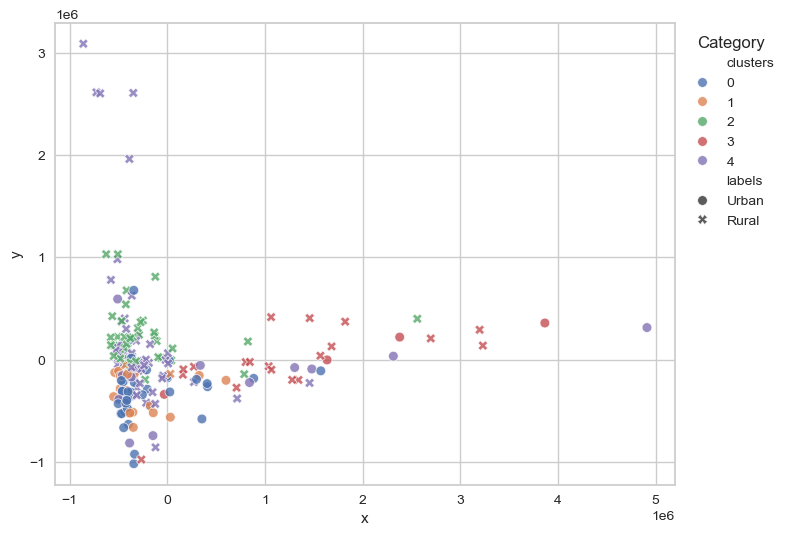

In [56]:
plot_clustering(taxonomy[clustering1.selected_features_], lifestyle, clusters1)

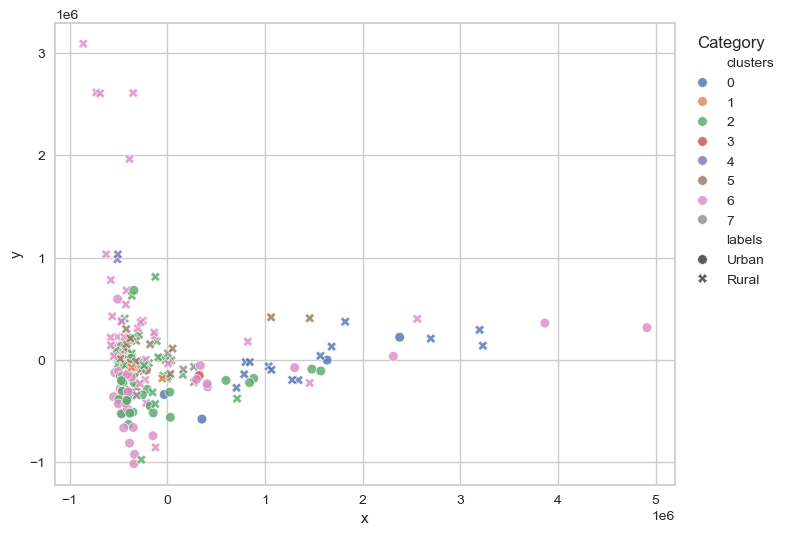

In [57]:
plot_clustering(taxonomy[clustering2.selected_features_], lifestyle, clusters2)

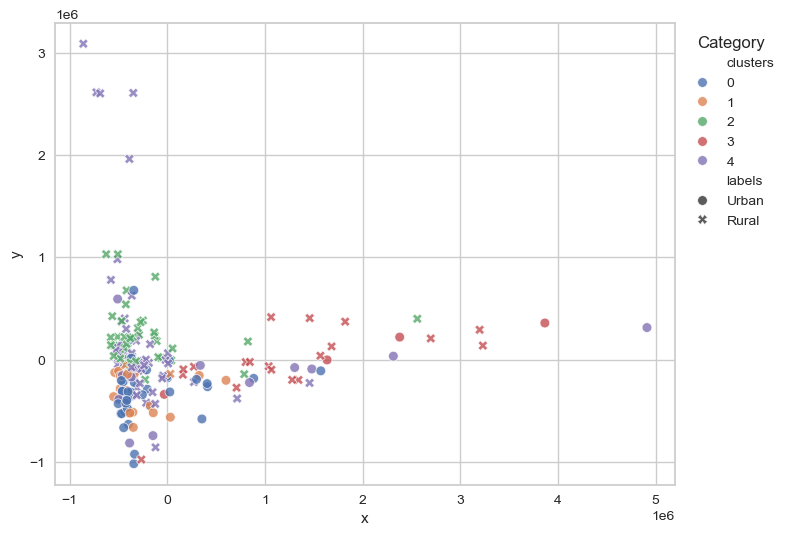

In [58]:
plot_clustering(taxonomy[clustering3.selected_features_], lifestyle, clusters3)

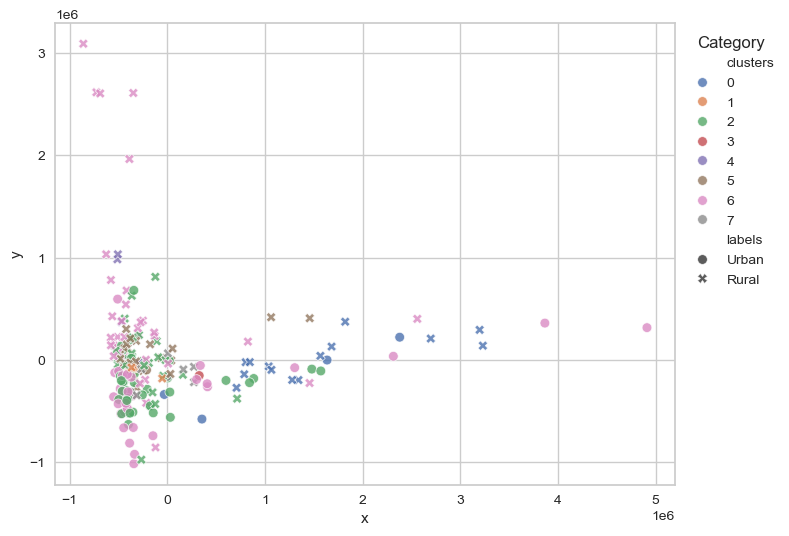

In [59]:
plot_clustering(taxonomy[clustering4.selected_features_], lifestyle, clusters4)

## Clusters Analysis

In [82]:
metadata

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,36703_3_13,36703_3#13,GI1_LA9438059,29,8,21839274,36703_3_13,Latinbiota,Healthy,NaN,23.8,NaN,32.0,Adult,Female,Rural,Mexico,North America
204,36703_3_12,36703_3#12,GI1_LA9438052,22,21,20889370,36703_3_12,Latinbiota,Healthy,NaN,25.6,NaN,10.0,Child,Female,Rural,Mexico,North America
205,36703_3_11,36703_3#11,GI1_LA9438050,B18,B17,21384690,36703_3_11,Latinbiota,Healthy,NaN,17.0,NaN,2.0,Infant,Male,Rural,Mexico,North America
206,36703_3_10,36703_3#10,GI1_LA9438043,C69,C68,21100234,36703_3_10,Latinbiota,Healthy,NaN,15.6,NaN,5.0,Child,Female,Urban,Mexico,North America


In [60]:
taxonomy_analysis = taxonomy[clustering1.selected_features_]
# taxonomy_analysis['Lifestyle'] = lifestyle
taxonomy_analysis['cluster'] = clusters1

In [61]:
clusters_df = []
for i in range(5):
    clusters_df.append(metadata[metadata['Lane'].isin(taxonomy_analysis[taxonomy_analysis['cluster']==i].index)])

In [62]:
def get_urban_rural_counts(cluster:pd.DataFrame):
    return len(cluster[cluster['Lifestyle'] == 'Urban']), len(cluster[cluster['Lifestyle'] == 'Rural'])

In [71]:
def get_health_state(cluster:pd.DataFrame):
    return len(cluster[cluster['Health state'] == 'Healthy']), len(cluster[cluster['Health state'] == 'Diseased'])

In [83]:
def get_gender(cluster:pd.DataFrame):
    return len(cluster[cluster['Gender'] == 'Male']), len(cluster[cluster['Gender'] == 'Female'])

In [84]:
percentages = dict()
health_states = dict()
genders = dict()
i = 1
for cluster in clusters_df:
    urban, rural = get_urban_rural_counts(cluster)
    healthy, unhealthy = get_health_state(cluster)
    male, female = get_gender(cluster)
    percentages[f'Cluster {i}'] = {'Urban':urban, 'Rural':rural}
    health_states[f'Cluster {i}'] = {'Healthy':healthy, 'Unhealthy':unhealthy}
    genders[f'Cluster {i}'] = {'Male':male, 'Female':female}
    i += 1

In [94]:
percentages

{'Cluster 1': {'Urban': 41, 'Rural': 2},
 'Cluster 2': {'Urban': 20, 'Rural': 2},
 'Cluster 3': {'Urban': 0, 'Rural': 44},
 'Cluster 4': {'Urban': 4, 'Rural': 19},
 'Cluster 5': {'Urban': 17, 'Rural': 50}}

In [78]:
health_states

{'Cluster 1': {'Healthy': 43, 'Unhealthy': 0},
 'Cluster 2': {'Healthy': 21, 'Unhealthy': 1},
 'Cluster 3': {'Healthy': 41, 'Unhealthy': 3},
 'Cluster 4': {'Healthy': 22, 'Unhealthy': 1},
 'Cluster 5': {'Healthy': 62, 'Unhealthy': 5}}

In [65]:
ages = dict()
i = 1
for cluster in clusters_df:
    ages[f'Cluster {i}'] = list(cluster['Age'].dropna())
    i += 1

In [66]:
bmi = dict()
i = 1
for cluster in clusters_df:
    bmi[f'Cluster {i}'] = list(cluster['BMI'].dropna())
    i += 1

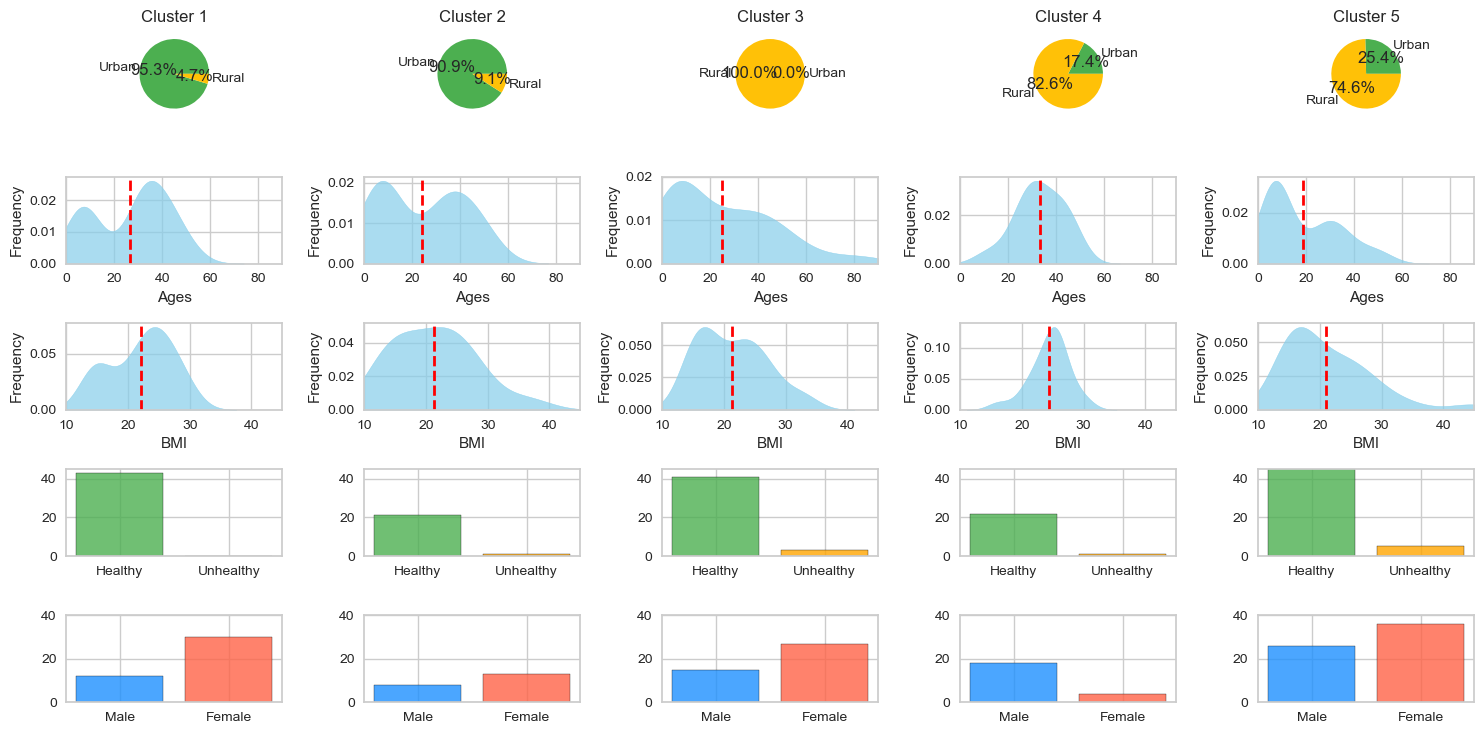

In [93]:
# Convert to a DataFrame
df = pd.DataFrame(percentages)
df2 = pd.DataFrame(health_states)
df3 = pd.DataFrame(genders)
# df2 = pd.DataFrame(ages)

# Create figure and axes grid
fig, axes = plt.subplots(5, len(df.columns), figsize=(15, 7.5))

# Add column headers
# for i, cluster in enumerate(df.columns):
#     axes[0, i].axis("off")  # Turn off axes for headers
#     axes[0, i].text(0.5, 0.5, cluster, fontsize=14, ha="center", va="center")

# Add pie charts
for i, cluster in enumerate(df.columns):
    axes[0, i].pie(
        df[cluster],
        labels=df.index,
        autopct="%1.1f%%",
        colors=["#4CAF50", "#FFC107"],
    )
    axes[0, i].set_title(cluster)

for i, (cluster, ages_list) in enumerate(ages.items()):
    # axes[1, i].hist(ages_list, bins=5, color="skyblue", edgecolor="black", alpha=0.7)
    sns.kdeplot(ages_list, ax=axes[1, i], color="skyblue", fill=True, alpha=0.7)
    axes[1, i].set_xlabel("Ages")
    axes[1, i].set_ylabel("Frequency")
    axes[1, i].set_xlim(0, 90)
    axes[1, i].axvline(np.mean(ages_list), color="red", linestyle="--", linewidth=2)

for i, (cluster, bmi_list) in enumerate(bmi.items()):
    # axes[2, i].hist(bmi_list, bins=4, color="skyblue", edgecolor="black", alpha=0.7)
    sns.kdeplot(bmi_list, ax=axes[2, i], color="skyblue", fill=True, alpha=0.7)
    axes[2, i].set_xlabel("BMI")
    axes[2, i].set_ylabel("Frequency")
    axes[2, i].set_xlim(10, 45)
    axes[2, i].axvline(np.mean(bmi_list), color="red", linestyle="--", linewidth=2)

for i, cluster in enumerate(df2.columns):
    axes[3, i].bar(
        df2.index,
        df2[cluster],
        color=["#4CAF50", "#FFA500"],
        alpha=0.8,
        edgecolor="black"
    )

    axes[3, i].set_ylim(0, 45)


for i, cluster in enumerate(df3.columns):
    axes[4, i].bar(
        df3.index,
        df3[cluster],
        color=["#1E90FF", "#FF6347"],
        alpha=0.8,
        edgecolor="black"
    )

    axes[4, i].set_ylim(0, 40)
    # axxes[0, i].set_title(cluster)
# Remove unused axes
# for ax in axes.flat[len(df.columns):]:
#     ax.axis("off")

# Adjust layout
plt.savefig('cluster_analysis.png', dpi = 500)
plt.tight_layout()
plt.show()


## Extra

In [155]:
def get_clustering_labels(data:pd.DataFrame, k:int = 2, algorithm:str = 'kmeans', filter_criteria:str = 'presence'):
        """
        Performs clustering on a given dataset using either KMeans or Gaussian Mixture, 
        with optional feature filtering by abundance or presence.
    
        Parameters:
        -----------
        data : pd.DataFrame
            The input dataset with features as columns and samples as rows. 
            Values should be continuous and non-negative.
            
        k : int, optional (default=2)
            The number of clusters to generate in the clustering algorithm.
    
        algorithm : str, optional (default='kmeans')
            The clustering algorithm to use. Options are:
            - 'kmeans': Uses KMeans clustering.
            - 'gaussian_mixture': Uses Gaussian Mixture Model clustering.
    
        filter_criteria : str, optional (default='presence')
            The criterion to filter features before clustering. Options are:
            - 'abundance': Retains features with total abundance greater than the mean abundance across all features.
            - 'presence': Retains features present in more than 25 samples.
    
        Returns:
        --------
        tuple
            - clusters : pd.DataFrame
                The scaled dataset used for clustering, filtered according to the specified criterion.
            - labels : np.ndarray
                The cluster labels for each sample.
    
        Prints:
        -------
        - Silhouette Score: Measure of how well samples are clustered.
        - Davies-Bouldin Score: Measure of cluster separation and compactness.
        - Calinski-Harabasz Score: Measure of cluster separation relative to the cluster's density.
        """
   
    if filter_criteria == 'abundance':
        column_sums = data.sum()

        mean_sum = column_sums.mean()
    
        filtered = data.loc[:, column_sums > mean_sum]
        
    elif filter_criteria == 'presence':
        binary_df = (data > 0).astype(int)
        binary_df = (data > 0).astype(int)
        presence = binary_df.sum(axis = 0) > 25
        filtered = data[presence[presence].index]
    
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(filtered)

    if algorithm == 'kmeans':
        kmeans = KMeans(n_clusters=k, n_init=1, max_iter = 1500, random_state=42).fit(data_scaled)
        labels = kmeans.labels_
        
    elif algorithm == 'gaussian_mixture':
        gm = GaussianMixture(n_components=2, max_iter = 1000, init_params = 'k-means++', random_state=42).fit(data_scaled)
        labels = gm.fit_predict(data_scaled)

    print(f'Silhoutte score: {silhouette_score(data_scaled, labels)}')
    print(f'Davies-Bouldin score: {davies_bouldin_score(data_scaled, labels)}')
    print(f'Calinksi-Harabasz score: {calinski_harabasz_score(data_scaled, labels)}')


    clusters = pd.DataFrame(data_scaled)
    clusters.columns = filtered.columns
    clusters.index = filtered.index

    return clusters, labels    

In [156]:
clusters1, taxonomy['kmeans_presence_clusters'] = get_clustering_labels(taxonomy, algorithm = 'kmeans', filter_criteria = 'presence')

Silhoutte score: 0.31191163742484773
Davies-Bouldin score: 1.3878480709142433
Calinksi-Harabasz score: 9.18827053288042


In [157]:
clusters2, taxonomy['kmeans_abundance_clusters'] = get_clustering_labels(taxonomy, algorithm = 'kmeans', filter_criteria = 'abundance')

Silhoutte score: 0.07766717594221446
Davies-Bouldin score: 3.1179030015558165
Calinksi-Harabasz score: 18.703742682778564


In [158]:
clusters3, taxonomy['gmm_presence_clusters'] = get_clustering_labels(taxonomy, algorithm = 'gaussian_mixture', filter_criteria = 'presence')

C:\Users\rafap\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\rafap\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


Silhoutte score: 0.31188268016034243
Davies-Bouldin score: 1.387861807533183
Calinksi-Harabasz score: 9.187715962935387


In [159]:
clusters4, taxonomy['gmm_abundance_clusters'] = get_clustering_labels(taxonomy, algorithm = 'gaussian_mixture', filter_criteria = 'abundance')

Silhoutte score: 0.13935320796162054
Davies-Bouldin score: 2.218796802331147
Calinksi-Harabasz score: 2.836773083365486


In [21]:
def plot_clustering(clusters_data:pd.DataFrame, metadata:pd.DataFrame, labels:list):
    """
    Visualize clustering results in a 2D PCA plot with additional metadata information.

    Parameters:
    -----------
    clusters_data : pd.DataFrame
        The scaled and filtered dataset used for clustering. Rows represent samples, and columns represent features.
    
    metadata : pd.DataFrame
        Metadata associated with the samples, containing at least the following columns:
        - 'Lane': Unique identifier matching the sample indices in `clusters_data`.
        - 'Lifestyle': Lifestyle category (e.g., rural or urban) for each sample.
        - 'BMI': Body Mass Index (BMI) value for each sample, used for categorization.

    labels : list
        Cluster labels for each sample, as obtained from the clustering algorithm.
    """
    pca = PCA(n_components=2)
    components = pca.fit_transform(clusters_data.to_numpy())
    components = pd.DataFrame(components)
    components['labels'] = labels
    components.columns = ['x', 'y', 'labels']
    components.index = clusters_data.index
    lifestyle = []
    bmi=[]
    for sample in components.index:
        lifestyle.append(metadata[metadata['Lane'] == sample]['Lifestyle'].iloc[0])
        try:
            if metadata[metadata['Lane'] == sample]['BMI'].iloc[0] >= 30:
                bmi.append('>30')
            else:
                bmi.append('<30')
        except:
            bmi.append('Not known')
    components['Lifestyle'] = lifestyle
    components['BMI'] = bmi
    
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=components, x='x', y='y', hue= 'labels', style = 'Lifestyle', size = 'BMI', size_order = ['>30', '<30'])
    plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

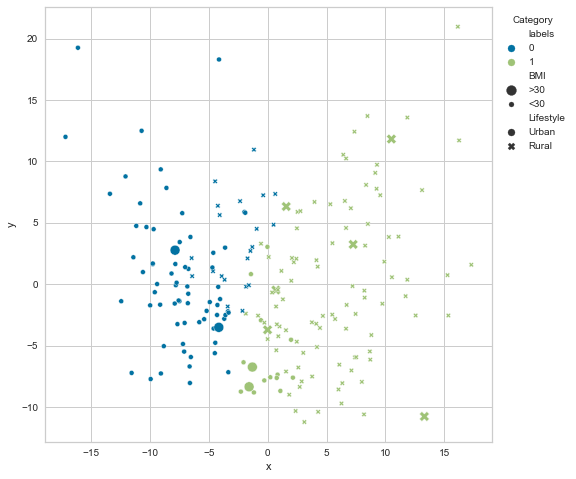

In [161]:
plot_clustering(clusters2, metadata, list(taxonomy['kmeans_abundance_clusters']))

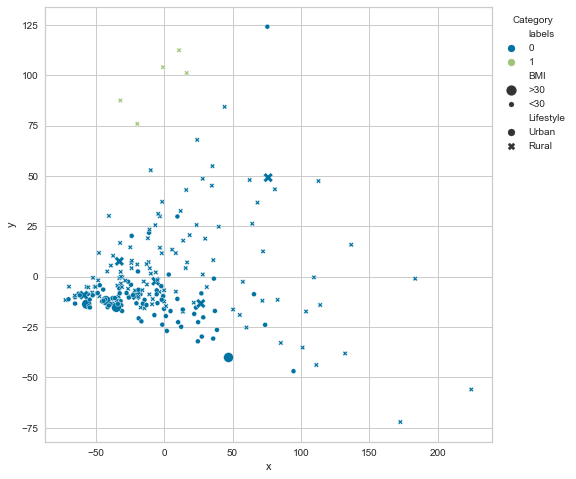

In [162]:
plot_clustering(clusters1, metadata, list(taxonomy['kmeans_presence_clusters']))

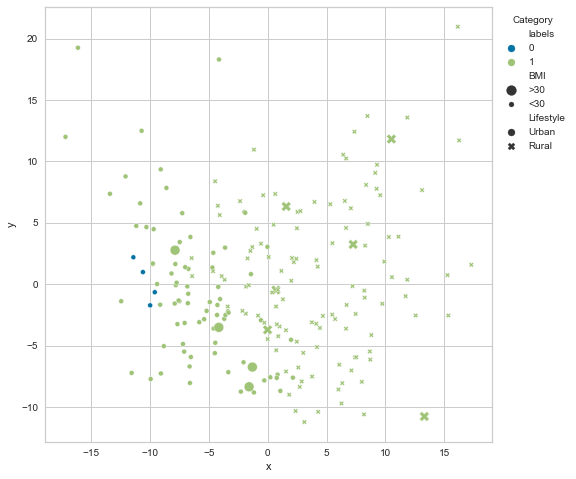

In [163]:
plot_clustering(clusters4, metadata, list(taxonomy['gmm_abundance_clusters']))

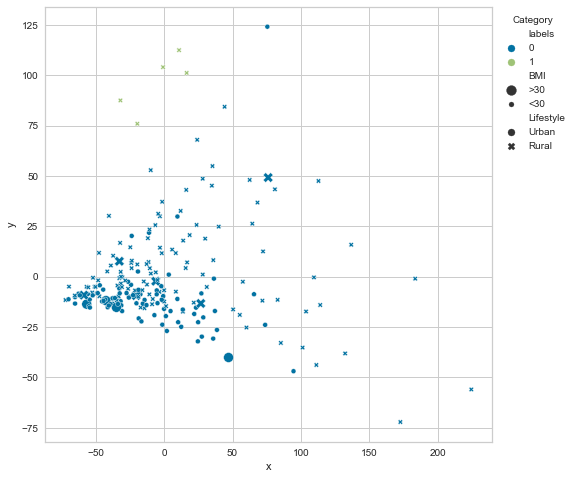

In [164]:
plot_clustering(clusters3, metadata, list(taxonomy['gmm_presence_clusters']))

In [165]:
clusters1, pathways['kmeans_presence_clusters'] = get_clustering_labels(pathways, algorithm = 'kmeans', filter_criteria = 'presence')

Silhoutte score: 0.6892982376269989
Davies-Bouldin score: 0.6797695584230666
Calinksi-Harabasz score: 77.3213809409749


In [166]:
clusters2, pathways['kmeans_abundance_clusters'] = get_clustering_labels(pathways, algorithm = 'kmeans', filter_criteria = 'abundance')

Silhoutte score: 0.3522449516573163
Davies-Bouldin score: 1.4079032220599808
Calinksi-Harabasz score: 64.7328798799655


In [167]:
clusters3, pathways['gmm_presence_clusters'] = get_clustering_labels(pathways, algorithm = 'gaussian_mixture', filter_criteria = 'presence')

Silhoutte score: 0.6902278821302333
Davies-Bouldin score: 0.6770236373764459
Calinksi-Harabasz score: 77.80769007388659


In [168]:
clusters4, pathways['gmm_abundance_clusters'] = get_clustering_labels(pathways, algorithm = 'gaussian_mixture', filter_criteria = 'abundance')

Silhoutte score: 0.5454492841344549
Davies-Bouldin score: 0.7611854581634364
Calinksi-Harabasz score: 40.50821772323873


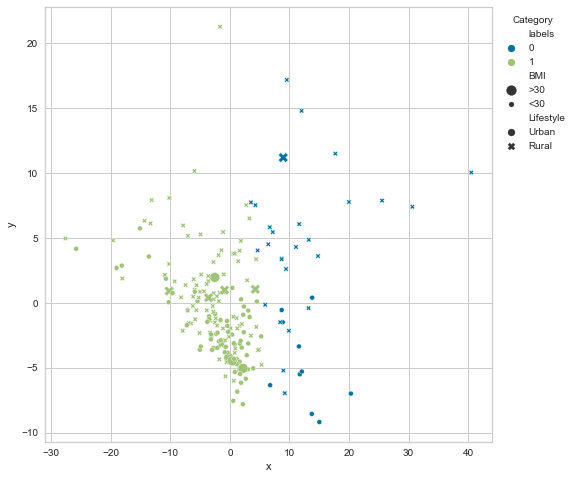

In [169]:
plot_clustering(clusters2, metadata, list(pathways['kmeans_abundance_clusters']))

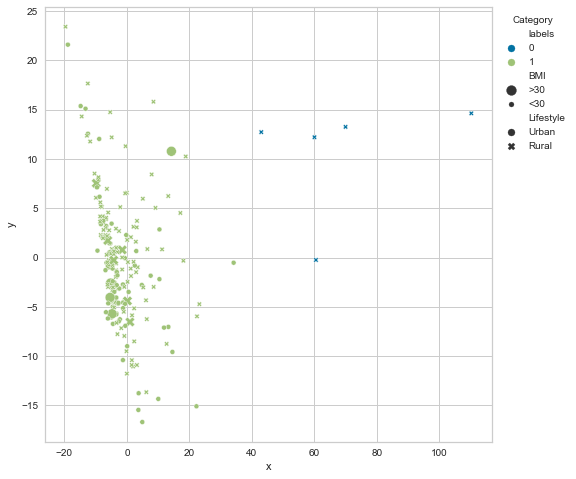

In [170]:
plot_clustering(clusters1, metadata, list(pathways['kmeans_presence_clusters']))

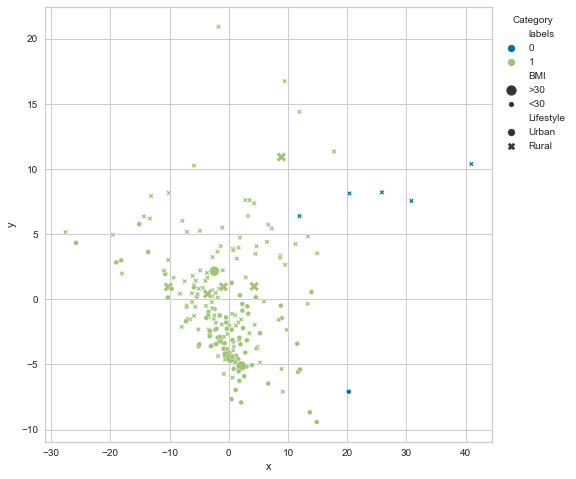

In [171]:
plot_clustering(clusters4, metadata, list(pathways['gmm_abundance_clusters']))

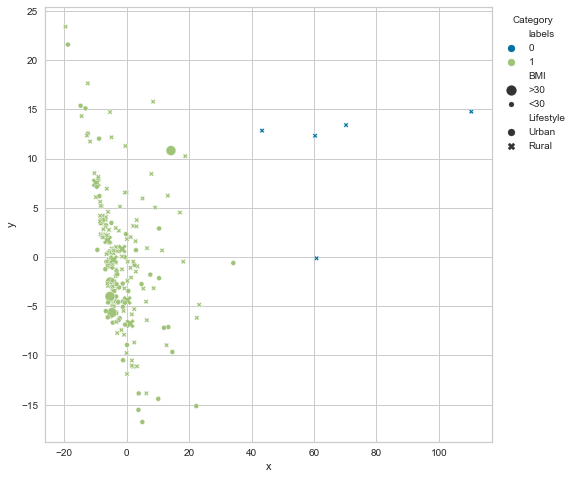

In [172]:
plot_clustering(clusters3, metadata, list(pathways['gmm_presence_clusters']))

In [121]:
pd.DataFrame(data_scaled_pathways, index = pathways.index)

,0,1,2,3,4,5,6,7,8,9,...,526,527,528,529,530,531,532,533,534,535
36703_3#10_paired_Abundance,-0.140944,0.948323,-0.221272,-0.263287,-0.082126,1.574739,0.504713,-0.361943,-0.290362,1.352519,...,-0.140026,-0.398253,-0.730296,-0.217445,-0.185973,0.231655,0.158114,0.469295,0.158114,0.17364
36703_3#12_paired_Abundance,-0.140944,0.486488,0.081800,-0.263287,0.676848,-0.080227,-0.478972,0.705243,0.225017,-0.278671,...,-0.140026,-0.398253,0.030914,0.158233,-0.185973,0.437269,0.158114,0.469295,0.158114,0.17364
36703_3#13_paired_Abundance,-0.140944,0.242750,-0.221272,-0.263287,-0.377544,-0.898119,0.177234,-0.234444,-0.290362,-0.551865,...,-0.140026,-0.398253,-0.838532,-0.217445,0.020754,0.359535,0.158114,0.469295,0.158114,0.17364
36703_3#14_paired_Abundance,-0.140944,0.343641,-0.221272,-0.263287,-0.377544,0.885985,0.113650,-0.058005,-0.290362,-0.578078,...,-0.140026,-0.398253,-0.048660,-0.217445,-0.185973,-0.670615,0.158114,0.469295,0.158114,0.17364
36703_3#15_paired_Abundance,-0.140944,-0.480709,-0.221272,-0.263287,-0.377544,0.572493,-0.158168,-0.616500,-0.290362,-0.578078,...,-0.140026,-0.398253,-0.061187,-0.217445,-0.185973,0.836923,0.158114,0.469295,0.158114,0.17364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5_paired_Abundance,-0.140944,0.700030,-0.221272,-0.263287,-0.377544,0.731225,0.984488,-0.713405,-0.290362,-0.455622,...,-0.140026,-0.398253,0.716405,-0.217445,-0.185973,0.471912,0.158114,0.469295,0.158114,0.17364
37082_3#6_paired_Abundance,-0.140944,-0.858739,-0.221272,-0.263287,-0.377544,-0.985448,-1.070270,-0.744408,-0.290362,-0.578078,...,-0.140026,-0.398253,-0.370784,-0.217445,-0.185973,-0.238688,0.158114,0.469295,0.158114,0.17364
37082_3#7_paired_Abundance,-0.140944,-0.374214,-0.221272,-0.263287,-0.377544,0.190806,-0.259520,-0.684655,-0.290362,-0.578078,...,-0.140026,0.016776,0.128836,-0.217445,-0.185973,-0.958465,0.158114,0.469295,0.158114,0.17364
37082_3#8_paired_Abundance,-0.140944,0.432491,-0.221272,-0.263287,-0.178688,0.071815,0.202036,-0.790564,-0.290362,-0.578078,...,-0.140026,3.581875,-0.278358,-0.217445,-0.185973,-0.293082,0.158114,0.469295,0.158114,0.17364


In [122]:
taxonomy

,2763670,46228,33039,33038,166486,301301,2763062,39485,418240,2479767,...,1923324,2845935,1475063,35783,103690,2734056,2419609,2704034,3048295,2845556
37035_2#16,597259.0,343254.0,39335.0,35129.0,225002.0,128437.0,25426.0,240332.0,53240.0,27147.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_3#26,4681.0,10905.0,81632.0,13430.0,20487.0,6363.0,4395.0,5792.0,522347.0,85723.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#13,749.0,1451.0,21871.0,1591.0,5019.0,3105.0,882.0,11461.0,12640.0,10090.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_1#27,3872.0,4599.0,86240.0,5501.0,17020.0,5048.0,2108.0,11433.0,295076.0,14710.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_1#17,90006.0,6411.0,113806.0,11018.0,60139.0,34079.0,8053.0,8525.0,25112.0,8832.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#13,8230.0,5638.0,39957.0,6629.0,56233.0,78750.0,7984.0,91982.0,20573.0,4719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#9,4953.0,4881.0,143488.0,5812.0,19461.0,6050.0,2554.0,68766.0,67981.0,13436.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_1#13,24629.0,10078.0,91015.0,15878.0,119840.0,40227.0,14961.0,67722.0,42818.0,8642.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37035_7#3,5205.0,9862.0,99575.0,8973.0,54036.0,21343.0,9214.0,380716.0,25627.0,8516.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


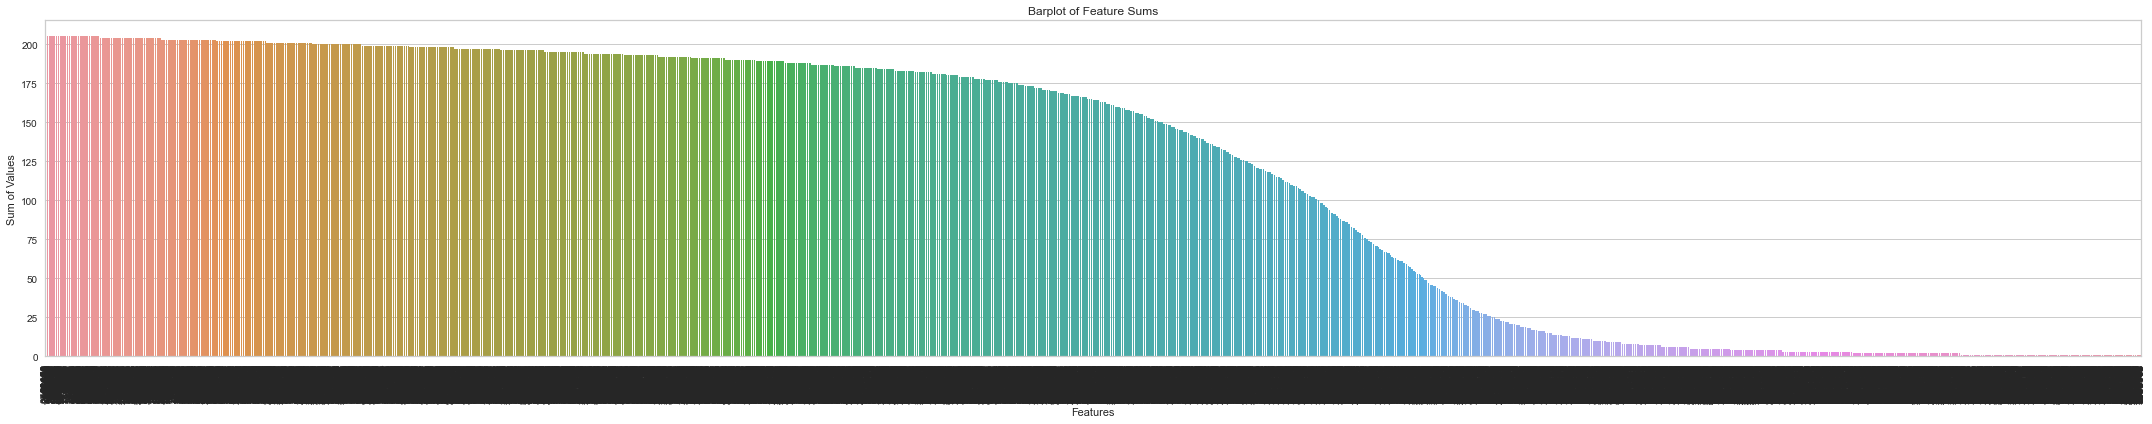

In [72]:
binary_df = (taxonomy > 0).astype(int)
series_data = binary_df.sum(axis=0)


data_to_plot = series_data.reset_index()
data_to_plot.columns = ['Feature', 'Count']


data_to_plot = data_to_plot.sort_values(by='Count', ascending = False)
# print(data_to_plot)


plt.figure(figsize=(30, 6))  
sns.barplot(x='Feature', y='Count', order = [x for x in list(data_to_plot['Feature'])],  data=data_to_plot)


plt.xticks(rotation=90)


plt.xlabel("Features")
plt.ylabel("Sum of Values")
plt.title("Barplot of Feature Sums")


plt.tight_layout()
plt.show()


In [253]:
scaler = StandardScaler()
taxonomy_scaled = scaler.fit_transform(taxonomy)

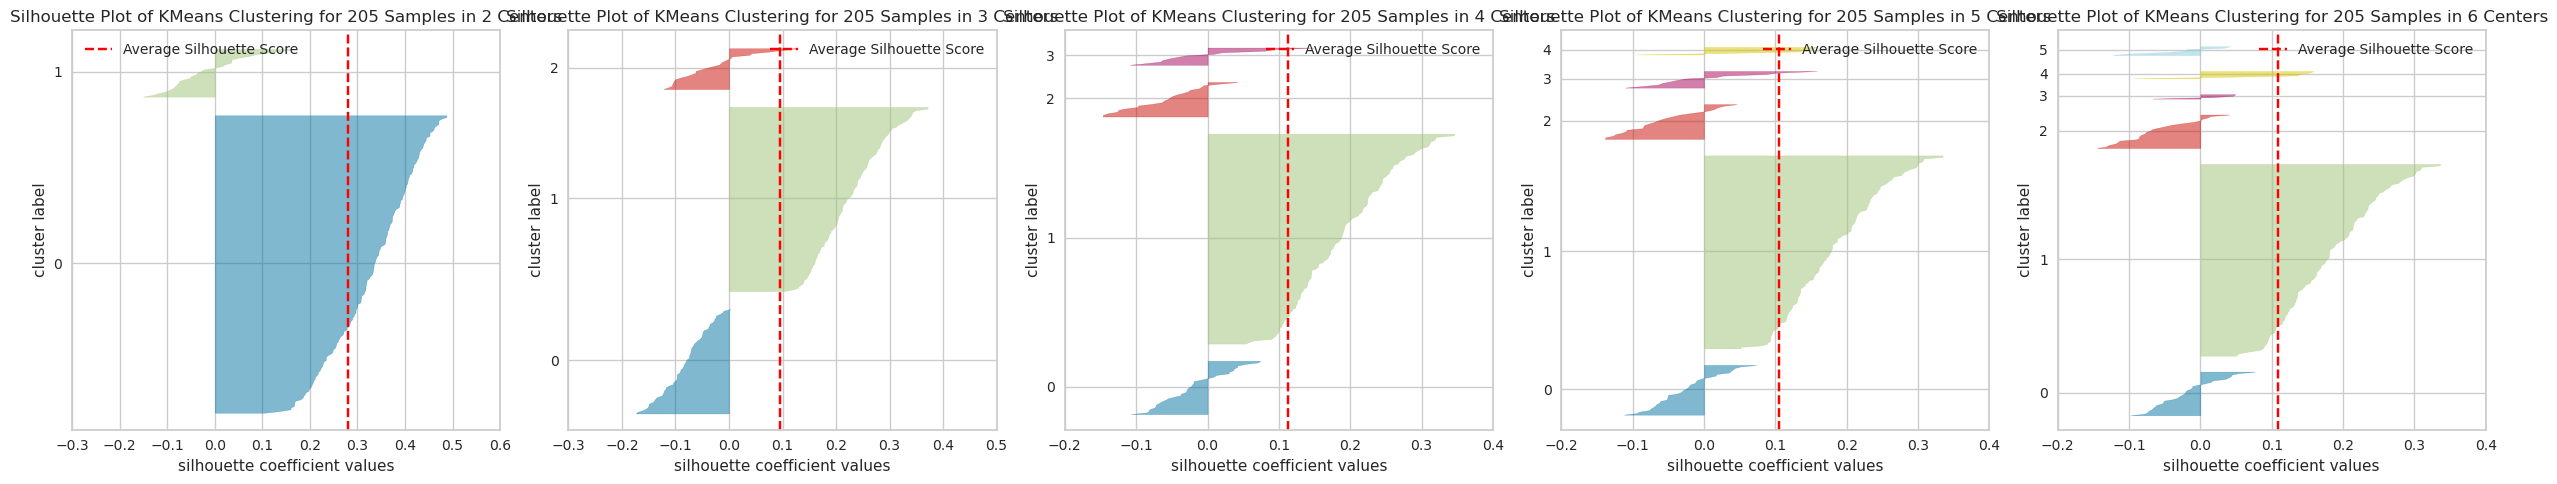

In [254]:
# Create a figure with subplots (one for each k)
k_values = [2, 3, 4, 5, 6]  # Different values of k to try
n_plots = len(k_values)

fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 5, 5))

# Loop over different k values and create a Silhouette plot for each
for ax, k in zip(axes, k_values):
    model = KMeans(k, random_state=42)
    visualizer = SilhouetteVisualizer(model, ax=ax, colors='yellowbrick')
    visualizer.fit(taxonomy_scaled)  # Fit the data to the visualizer
    visualizer.finalize()  # Finalize the plot for each subplot

# Show the entire multiplot figure
plt.tight_layout()
plt.show()

In [255]:
# filtered_df = df[df.sum(axis=1) > threshold]

In [256]:
sumas = []
for col in taxonomy:
    sumas.append(sum(taxonomy[col]))

In [257]:
statistics.mean(sumas), statistics.stdev(sumas), statistics.median(sumas)

(83013.81698573435, 1401729.8351648198, 1411.0)

In [258]:
# taxonomy_filtered = taxonomy[taxonomy.sum(axis=1) > 5903013.8169]

In [259]:
taxonomy_filtered = taxonomy.loc[:, taxonomy.sum() > 83013.81]

In [260]:
taxonomy_filtered

,2763670,46228,33039,33038,166486,301301,2763062,39485,418240,2479767,...,2955741,2955762,2955583,2955582,2955562,2956060,2955560,2955726,2985571,2955727
37035_2#16,597259.0,343254.0,39335.0,35129.0,225002.0,128437.0,25426.0,240332.0,53240.0,27147.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
37082_3#26,4681.0,10905.0,81632.0,13430.0,20487.0,6363.0,4395.0,5792.0,522347.0,85723.0,...,1.0,19.0,14.0,4.0,2.0,1.0,0.0,0.0,0.0,0.0
37035_7#13,749.0,1451.0,21871.0,1591.0,5019.0,3105.0,882.0,11461.0,12640.0,10090.0,...,0.0,0.0,0.0,3.0,398.0,0.0,577.0,0.0,0.0,0.0
37035_1#27,3872.0,4599.0,86240.0,5501.0,17020.0,5048.0,2108.0,11433.0,295076.0,14710.0,...,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,0.0,0.0
37082_1#17,90006.0,6411.0,113806.0,11018.0,60139.0,34079.0,8053.0,8525.0,25112.0,8832.0,...,122.0,0.0,0.0,0.0,3083.0,0.0,4046.0,22.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#13,8230.0,5638.0,39957.0,6629.0,56233.0,78750.0,7984.0,91982.0,20573.0,4719.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,300.0,0.0
37035_7#9,4953.0,4881.0,143488.0,5812.0,19461.0,6050.0,2554.0,68766.0,67981.0,13436.0,...,2.0,0.0,0.0,0.0,1672.0,0.0,9810.0,0.0,0.0,0.0
37082_1#13,24629.0,10078.0,91015.0,15878.0,119840.0,40227.0,14961.0,67722.0,42818.0,8642.0,...,146.0,0.0,0.0,0.0,0.0,0.0,2.0,38.0,0.0,143.0
37035_7#3,5205.0,9862.0,99575.0,8973.0,54036.0,21343.0,9214.0,380716.0,25627.0,8516.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [261]:
scaler = StandardScaler()
taxonomy_scaled = scaler.fit_transform(taxonomy_filtered)

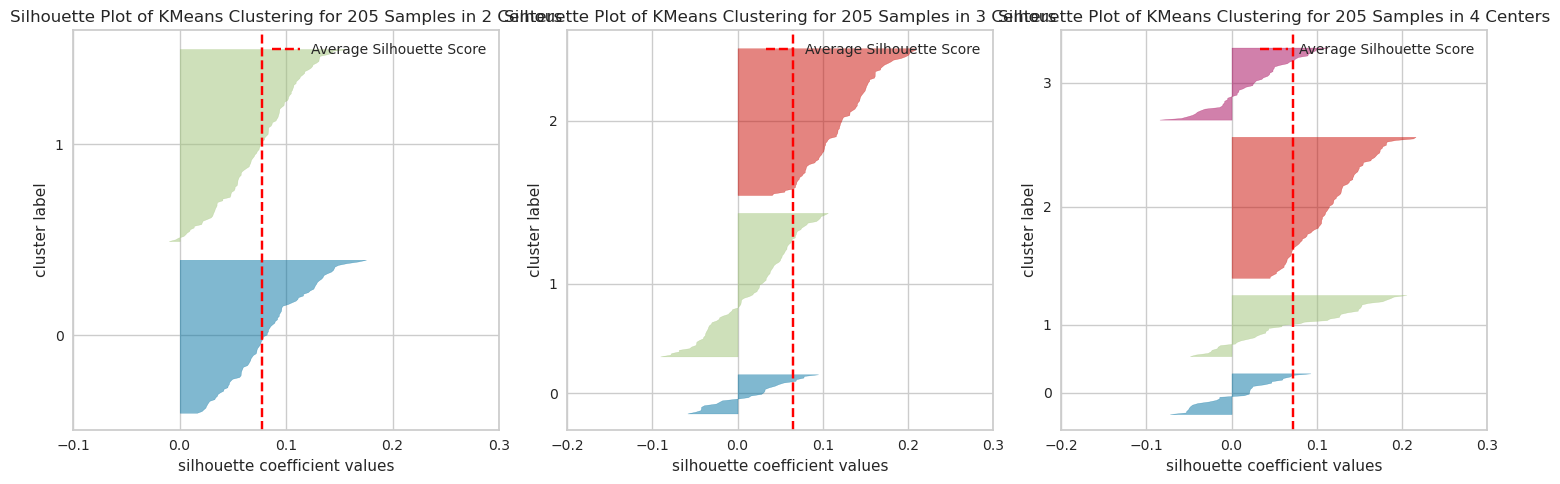

In [262]:
# Create a figure with subplots (one for each k)
k_values = [2, 3, 4]  # Different values of k to try
n_plots = len(k_values)

fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 5, 5))

# Loop over different k values and create a Silhouette plot for each
for ax, k in zip(axes, k_values):
    model = KMeans(k, random_state=42)
    visualizer = SilhouetteVisualizer(model, ax=ax, colors='yellowbrick')
    visualizer.fit(taxonomy_scaled)  # Fit the data to the visualizer
    visualizer.finalize()  # Finalize the plot for each subplot

# Show the entire multiplot figure
plt.tight_layout()
plt.show()

In [263]:
kmeans = KMeans(n_clusters=2, n_init=1, max_iter = 1000).fit(taxonomy_scaled)

In [264]:
kmeans.labels_

array([0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0], dtype=int32)

In [265]:
taxonomy_clusters = pd.DataFrame(taxonomy_scaled)

In [266]:
taxonomy_clusters.columns = taxonomy_filtered.columns

In [267]:
taxonomy_clusters.index = taxonomy_filtered.index

In [268]:
taxonomy_clusters['labels'] = kmeans.labels_

In [269]:
taxonomy_clusters

,2763670,46228,33039,33038,166486,301301,2763062,39485,418240,2479767,...,2955762,2955583,2955582,2955562,2956060,2955560,2955726,2985571,2955727,labels
37035_2#16,9.225687,2.778054,-0.468355,0.751162,1.085667,3.258090,1.703087,1.958067,-0.441854,0.286940,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278226,-0.070956,-0.351854,-0.072248,0
37082_3#26,-0.371814,-0.231357,-0.039859,-0.158611,-0.465901,-0.733429,-0.480288,-0.398926,1.786484,2.960787,...,-0.070377,-0.183601,-0.179567,-0.288126,-0.155608,-0.278226,-0.070956,-0.351854,-0.072248,1
37035_7#13,-0.435498,-0.316963,-0.645276,-0.654983,-0.583251,-0.839957,-0.844997,-0.341956,-0.634711,-0.491670,...,-0.071847,-0.186451,-0.179604,-0.247820,-0.155895,-0.233463,-0.070956,-0.351854,-0.072248,1
37035_1#27,-0.384917,-0.288458,0.006823,-0.491049,-0.492204,-0.776426,-0.717717,-0.342237,0.706908,-0.280778,...,-0.071847,-0.186451,-0.179716,-0.288126,-0.155895,-0.277683,-0.070956,-0.351854,-0.072248,1
37082_1#17,1.010125,-0.272050,0.286084,-0.259738,-0.165079,0.172816,-0.100525,-0.371461,-0.575467,-0.549094,...,-0.071847,-0.186451,-0.179716,0.025470,-0.155895,0.035652,-0.068492,-0.351854,-0.072248,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#13,-0.314334,-0.279050,-0.462053,-0.443756,-0.194712,1.633448,-0.107689,0.467234,-0.597028,-0.736842,...,-0.071847,-0.186451,-0.179716,-0.288025,-0.155895,-0.278226,-0.070956,-0.197473,-0.072248,1
37035_7#9,-0.367409,-0.285904,0.586782,-0.478010,-0.473685,-0.743663,-0.671415,0.233927,-0.371832,-0.338933,...,-0.071847,-0.186451,-0.179716,-0.118147,-0.155895,0.482808,-0.070956,-0.351854,-0.072248,1
37082_1#13,-0.048733,-0.238846,0.055197,-0.055973,0.287847,0.373841,0.616642,0.223435,-0.491360,-0.557767,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278070,-0.066699,-0.351854,-0.048104,0
37035_7#3,-0.363328,-0.240801,0.141915,-0.345479,-0.211380,-0.243619,0.020006,3.368846,-0.573021,-0.563519,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278226,-0.070956,-0.351854,-0.072248,1


In [270]:
taxonomy_clusters

,2763670,46228,33039,33038,166486,301301,2763062,39485,418240,2479767,...,2955762,2955583,2955582,2955562,2956060,2955560,2955726,2985571,2955727,labels
37035_2#16,9.225687,2.778054,-0.468355,0.751162,1.085667,3.258090,1.703087,1.958067,-0.441854,0.286940,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278226,-0.070956,-0.351854,-0.072248,0
37082_3#26,-0.371814,-0.231357,-0.039859,-0.158611,-0.465901,-0.733429,-0.480288,-0.398926,1.786484,2.960787,...,-0.070377,-0.183601,-0.179567,-0.288126,-0.155608,-0.278226,-0.070956,-0.351854,-0.072248,1
37035_7#13,-0.435498,-0.316963,-0.645276,-0.654983,-0.583251,-0.839957,-0.844997,-0.341956,-0.634711,-0.491670,...,-0.071847,-0.186451,-0.179604,-0.247820,-0.155895,-0.233463,-0.070956,-0.351854,-0.072248,1
37035_1#27,-0.384917,-0.288458,0.006823,-0.491049,-0.492204,-0.776426,-0.717717,-0.342237,0.706908,-0.280778,...,-0.071847,-0.186451,-0.179716,-0.288126,-0.155895,-0.277683,-0.070956,-0.351854,-0.072248,1
37082_1#17,1.010125,-0.272050,0.286084,-0.259738,-0.165079,0.172816,-0.100525,-0.371461,-0.575467,-0.549094,...,-0.071847,-0.186451,-0.179716,0.025470,-0.155895,0.035652,-0.068492,-0.351854,-0.072248,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36703_3#13,-0.314334,-0.279050,-0.462053,-0.443756,-0.194712,1.633448,-0.107689,0.467234,-0.597028,-0.736842,...,-0.071847,-0.186451,-0.179716,-0.288025,-0.155895,-0.278226,-0.070956,-0.197473,-0.072248,1
37035_7#9,-0.367409,-0.285904,0.586782,-0.478010,-0.473685,-0.743663,-0.671415,0.233927,-0.371832,-0.338933,...,-0.071847,-0.186451,-0.179716,-0.118147,-0.155895,0.482808,-0.070956,-0.351854,-0.072248,1
37082_1#13,-0.048733,-0.238846,0.055197,-0.055973,0.287847,0.373841,0.616642,0.223435,-0.491360,-0.557767,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278070,-0.066699,-0.351854,-0.048104,0
37035_7#3,-0.363328,-0.240801,0.141915,-0.345479,-0.211380,-0.243619,0.020006,3.368846,-0.573021,-0.563519,...,-0.071847,-0.186451,-0.179716,-0.288330,-0.155895,-0.278226,-0.070956,-0.351854,-0.072248,1


In [271]:
taxonomy_clusters.drop('labels', axis = 1).to_numpy().shape

(205, 411)

In [272]:
pca = PCA(n_components=2)
components = pca.fit_transform(taxonomy_clusters.drop('labels', axis = 1).to_numpy())

In [273]:
components = pd.DataFrame(components)

In [274]:
components['labels'] = list(taxonomy_clusters['labels'])

In [275]:
components.columns = ['x', 'y', 'labels']

In [276]:
components.index = taxonomy.index

In [277]:
lifestyle = []
bmi=[]
for sample in components.index:
    lifestyle.append(metadata[metadata['Lane'] == sample]['Lifestyle'].iloc[0])
    try:
        if metadata[metadata['Lane'] == sample]['BMI'].iloc[0] >= 30:
            bmi.append('>30')
        else:
            bmi.append('<30')
    except:
        bmi.append('Not known')

In [278]:
components['Lifestyle'] = lifestyle

In [279]:
components['BMI'] = bmi

In [280]:
components

,x,y,labels,Lifestyle,BMI
37035_2#16,10.314273,4.646578,0,Urban,<30
37082_3#26,-6.661547,4.573417,1,Rural,<30
37035_7#13,-4.290333,-10.399920,1,Rural,<30
37035_1#27,-7.417190,-5.966560,1,Rural,<30
37082_1#17,4.277656,-1.700740,0,Urban,<30
...,...,...,...,...,...
36703_3#13,0.006022,-4.478311,1,Rural,<30
37035_7#9,-6.661691,-3.629493,1,Rural,<30
37082_1#13,6.834542,-0.188909,0,Urban,<30
37035_7#3,-2.605712,-6.788298,1,Rural,<30


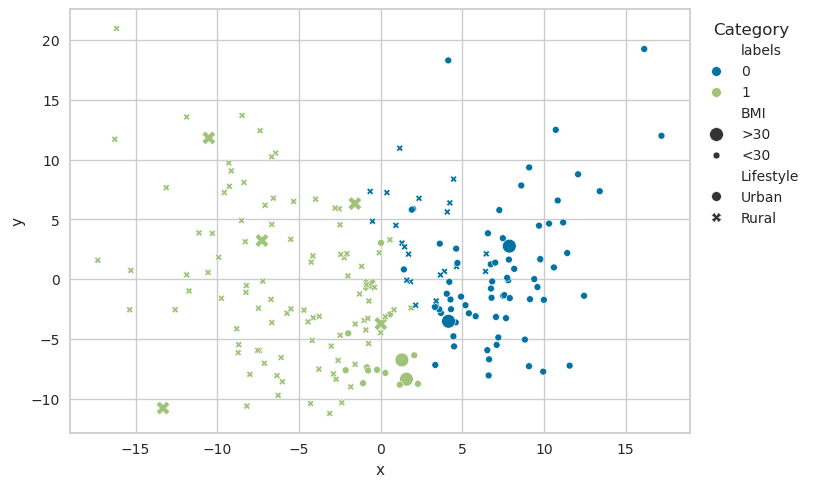

In [281]:
sns.scatterplot(data=components, x='x', y='y', hue= 'labels', style = 'Lifestyle', size = 'BMI', size_order = ['>30', '<30'])
plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

In [282]:
pathways_unstratified = pd.read_csv('../data/latinbiota_pathabundance_unstratified.tsv', sep = '\t', index_col = 0)

In [283]:
pathways_unstratified = pathways_unstratified[[x for x in pathways_unstratified.columns if '.1' not in x]]

In [284]:
pathways_unstratified.head()

,36703_3#10_paired_Abundance,36703_3#12_paired_Abundance,36703_3#13_paired_Abundance,36703_3#14_paired_Abundance,36703_3#15_paired_Abundance,36703_3#16_paired_Abundance,36703_3#17_paired_Abundance,36703_3#18_paired_Abundance,36703_3#19_paired_Abundance,36703_3#1_paired_Abundance,...,37082_3#30_paired_Abundance,37082_3#31_paired_Abundance,37082_3#32_paired_Abundance,37082_3#3_paired_Abundance,37082_3#4_paired_Abundance,37082_3#5_paired_Abundance,37082_3#6_paired_Abundance,37082_3#7_paired_Abundance,37082_3#8_paired_Abundance,37082_3#9_paired_Abundance
# Pathway,,,,,,,,,,,,,,,,,,,,,
UNMAPPED,1.381578e+06,2.078961e+06,1.855504e+06,3.009860e+06,1.417247e+06,2.902545e+06,2.866647e+06,2.713916e+06,1.722858e+06,1.346742e+06,...,2.300154e+06,3.034567e+06,2.431293e+06,2.074856e+06,3.385522e+06,1.935439e+06,1.497354e+06,2.600297e+06,2.874756e+06,2.157579e+06
UNINTEGRATED,6.757688e+06,5.721013e+06,5.864376e+06,8.289880e+06,5.392752e+06,6.351360e+06,8.734910e+06,4.412110e+06,5.046192e+06,5.471950e+06,...,5.617563e+06,7.040756e+06,5.907521e+06,1.328117e+07,8.185759e+06,6.551567e+06,4.672036e+06,4.399806e+06,5.526166e+06,5.893423e+06
"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1CMET2-PWY: folate transformations III (E. coli),3.238936e+03,2.861984e+03,2.663043e+03,2.745391e+03,2.072550e+03,3.530360e+03,3.220312e+03,1.981636e+03,1.780786e+03,2.461854e+03,...,3.019195e+03,2.484890e+03,2.518335e+03,5.431864e+03,2.895454e+03,3.036278e+03,1.764000e+03,2.159472e+03,2.817911e+03,2.803583e+03
3-HYDROXYPHENYLACETATE-DEGRADATION-PWY: 4-hydroxyphenylacetate degradation,0.000000e+00,3.949481e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.184164e+01,0.000000e+00,2.515445e+01,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.307616e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [285]:
pathways_unstratified.drop('UNMAPPED', axis = 0, inplace = True)
pathways_unstratified.drop('UNINTEGRATED', axis = 0, inplace = True)

In [286]:
pathways_unstratified = pathways_unstratified.T

In [287]:
pathways_unstratified.describe()

# Pathway,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",1CMET2-PWY: folate transformations III (E. coli),3-HYDROXYPHENYLACETATE-DEGRADATION-PWY: 4-hydroxyphenylacetate degradation,AEROBACTINSYN-PWY: aerobactin biosynthesis,ALLANTOINDEG-PWY: superpathway of allantoin degradation in yeast,ANAEROFRUCAT-PWY: homolactic fermentation,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,"ARGDEG-PWY: superpathway of L-arginine, putrescine, and 4-aminobutanoate degradation",ARGININE-SYN4-PWY: L-ornithine biosynthesis II,...,THREOCAT-PWY: superpathway of L-threonine metabolism,THRESYN-PWY: superpathway of L-threonine biosynthesis,TRNA-CHARGING-PWY: tRNA charging,TRPSYN-PWY: L-tryptophan biosynthesis,UBISYN-PWY: superpathway of ubiquinol-8 biosynthesis (early decarboxylation),UDPNACETYLGALSYN-PWY: UDP-N-acetyl-D-glucosamine biosynthesis II,UDPNAGSYN-PWY: UDP-N-acetyl-D-glucosamine biosynthesis I,URDEGR-PWY: superpathway of allantoin degradation in plants,URSIN-PWY: ureide biosynthesis,VALSYN-PWY: L-valine biosynthesis
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,...,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.180172,2464.908692,28.835094,5.627666,36.623729,2344.279815,3864.737598,498.116000,63.683089,234.254665,...,83.144283,2117.665969,4088.519805,2682.998300,12.935749,29.396439,2590.383032,8.358565,7.308115,4334.243209
std,1.281449,818.204815,130.634008,21.426999,97.242551,939.011415,993.039650,631.619386,219.860125,406.222225,...,210.177528,938.920332,1094.317125,1081.901947,92.607436,73.994174,1349.194934,38.533997,39.392929,1475.048903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2052.530926,0.000000,0.000000,0.000000,1648.624898,3382.523218,124.514172,0.000000,0.000000,...,0.000000,1523.903885,3493.852257,2023.008982,0.000000,0.000000,1653.371620,0.000000,0.000000,3550.784313
50%,0.000000,2533.609133,0.000000,0.000000,0.000000,2299.280838,3942.824777,306.404376,0.000000,81.764351,...,0.000000,2019.663343,4144.777506,2689.186533,0.000000,0.000000,2494.166390,0.000000,0.000000,4295.060141
75%,0.000000,2895.454436,7.227996,0.000000,39.798584,2973.327535,4356.884077,591.897757,33.885237,263.556778,...,63.579957,2560.240394,4673.276289,3289.182413,0.000000,16.698409,3248.945853,4.625472,0.000000,5313.872913
max,9.855236,5431.863661,1307.615784,173.816712,1219.949681,5947.291335,7166.349540,4490.816497,2229.838543,2620.609642,...,1903.176841,6819.733848,7296.874662,6910.312422,1204.129650,539.294359,8016.782595,385.108813,376.655805,9859.103404


In [288]:
sumas = []
for col in pathways_unstratified:
    sumas.append(sum(pathways_unstratified[col]))

In [289]:
statistics.mean(sumas), statistics.stdev(sumas), statistics.median(sumas)

(153661.05078722487, 237682.40560076514, 41078.093332501994)

In [290]:
pathways_filtered = pathways_unstratified.loc[:, pathways_unstratified.sum() > 41078.09]

In [291]:
pathways_filtered

# Pathway,1CMET2-PWY: folate transformations III (E. coli),ANAEROFRUCAT-PWY: homolactic fermentation,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),ARG+POLYAMINE-SYN: superpathway of arginine and polyamine biosynthesis,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),ARO-PWY: chorismate biosynthesis I,ASPASN-PWY: superpathway of L-aspartate and L-asparagine biosynthesis,BIOTIN-BIOSYNTHESIS-PWY: biotin biosynthesis I,...,SULFATE-CYS-PWY: superpathway of sulfate assimilation and cysteine biosynthesis,TCA-GLYOX-BYPASS: superpathway of glyoxylate bypass and TCA,TCA: TCA cycle I (prokaryotic),THISYN-PWY: superpathway of thiamine diphosphate biosynthesis I,THISYNARA-PWY: superpathway of thiamine diphosphate biosynthesis III (eukaryotes),THRESYN-PWY: superpathway of L-threonine biosynthesis,TRNA-CHARGING-PWY: tRNA charging,TRPSYN-PWY: L-tryptophan biosynthesis,UDPNAGSYN-PWY: UDP-N-acetyl-D-glucosamine biosynthesis I,VALSYN-PWY: L-valine biosynthesis
36703_3#10_paired_Abundance,3238.935931,3819.366400,4364.713229,270.063894,782.336325,2564.019848,2617.843489,4040.265620,1891.698942,431.262140,...,162.609614,107.613279,364.983336,495.767937,1227.212802,1793.932522,2952.519078,3721.047968,1607.477117,4675.110812
36703_3#12_paired_Abundance,2861.983652,2269.129396,3390.260940,942.473491,121.328870,3620.220086,3787.243038,4285.326520,1232.109040,472.714255,...,1026.063164,490.506992,577.083455,781.619792,885.629258,2115.570283,4200.299066,2962.629862,2631.989758,4977.660608
36703_3#13_paired_Abundance,2663.042553,1502.995266,4040.308071,350.398063,10.622245,3249.012356,3317.601737,3924.913859,1251.106795,416.413380,...,405.424868,62.927683,286.989591,1136.212906,863.146287,2171.647391,3727.901837,2929.469237,1461.802144,4863.279813
36703_3#14_paired_Abundance,2745.390883,3174.198641,3977.320774,461.568508,0.000000,2350.075499,2386.627023,3582.597794,1656.257475,81.690053,...,248.431877,22.629378,96.374759,187.054852,1444.026918,2356.726591,3751.098739,2112.816553,2524.891372,3347.468185
36703_3#15_paired_Abundance,2072.550380,2880.544873,3708.053625,109.673846,0.000000,3989.087750,4029.658651,4791.670543,1353.941073,151.719176,...,79.275859,0.000000,0.000000,100.017651,1159.540608,2798.479451,3307.224286,3113.602635,2508.031770,5565.730980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#5_paired_Abundance,3036.277676,3029.231709,4839.985770,48.616176,49.622741,4237.300341,4399.608269,4789.863735,1292.898448,193.221356,...,182.410005,0.000000,40.588878,350.008194,1011.517507,3040.366629,4714.701813,2414.716627,3554.591996,5028.636818
37082_3#6_paired_Abundance,1764.000042,1421.192985,2804.512594,29.081440,0.000000,2761.950173,2947.266055,3262.792401,1044.140275,171.740782,...,60.916116,0.000000,56.286637,303.234485,330.979021,2101.091538,2535.456249,1553.609640,2091.344933,3983.026316
37082_3#7_paired_Abundance,2159.472320,2523.011059,3607.653084,66.730812,0.000000,2804.976127,2960.831946,2952.471363,869.982856,54.689058,...,283.937550,0.000000,0.000000,342.512084,270.906339,1841.628036,5567.736463,1347.654046,2763.783743,2923.912747
37082_3#8_paired_Abundance,2817.910960,2411.550512,4064.877343,0.000000,0.000000,3319.379770,3533.489420,4058.556735,1439.811251,308.225709,...,162.619752,0.000000,0.000000,516.195784,578.157836,2526.757708,5465.873968,2060.033865,2215.740504,3902.988721


In [292]:
scaler = StandardScaler()
pathways_scaled = scaler.fit_transform(pathways_filtered)

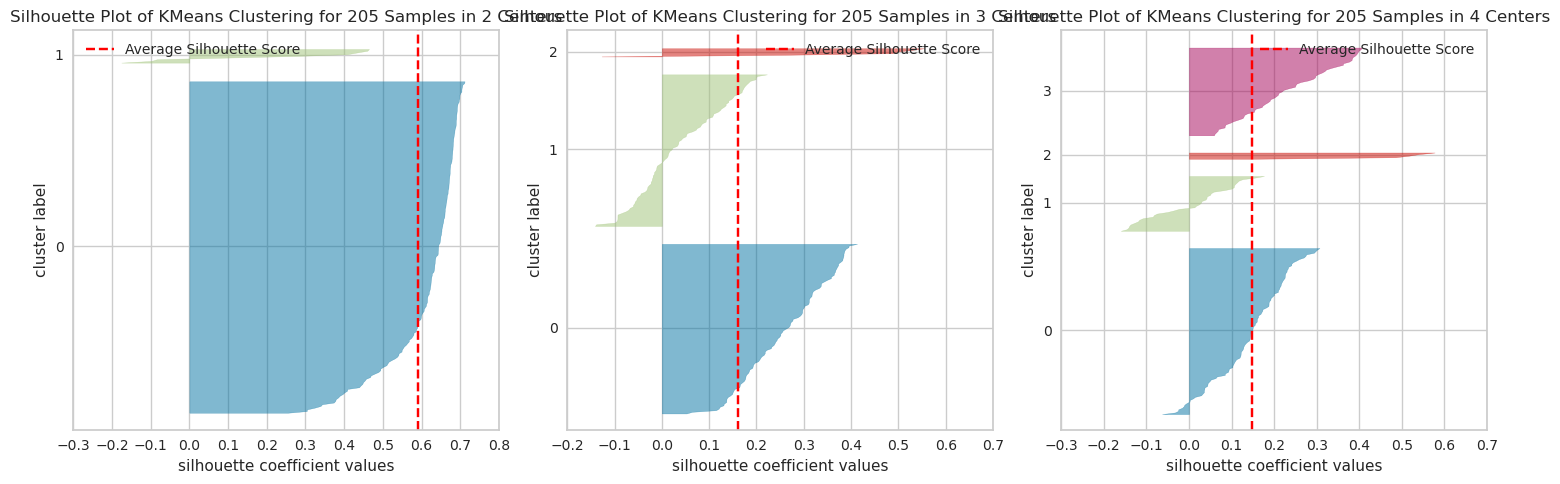

In [293]:
# Create a figure with subplots (one for each k)
k_values = [2, 3, 4]  # Different values of k to try
n_plots = len(k_values)

fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 5, 5))

# Loop over different k values and create a Silhouette plot for each
for ax, k in zip(axes, k_values):
    model = KMeans(k, random_state=42)
    visualizer = SilhouetteVisualizer(model, ax=ax, colors='yellowbrick')
    visualizer.fit(pathways_scaled)  # Fit the data to the visualizer
    visualizer.finalize()  # Finalize the plot for each subplot

# Show the entire multiplot figure
plt.tight_layout()
plt.show()

In [294]:
kmeans = KMeans(n_clusters=2, n_init=1, max_iter = 1000).fit(pathways_scaled)

In [295]:
pathways_clusters = pd.DataFrame(pathways_scaled)
pathways_clusters.columns = pathways_filtered.columns
pathways_clusters.index = pathways_filtered.index
pathways_clusters['labels'] = kmeans.labels_

In [296]:
pca = PCA(n_components=2)
components = pca.fit_transform(pathways_clusters.drop('labels', axis = 1).to_numpy())

In [297]:
components = pd.DataFrame(components)
components['labels'] = list(pathways_clusters['labels'])
components.columns = ['x', 'y', 'labels']
components.index = pathways_unstratified.index

In [298]:
lifestyle = []
bmi = []
for sample in components.index:
    aux = sample.replace('_paired_Abundance', '')
    lifestyle.append(metadata[metadata['Lane'] == aux]['Lifestyle'].iloc[0])
    try:
        if metadata[metadata['Lane'] == aux]['BMI'].iloc[0] >= 30:
            bmi.append('>30')
        else:
            bmi.append('<30')
    except:
        bmi.append('Not known')

In [299]:
components['Lifestyle'] = lifestyle
components['BMI'] = bmi

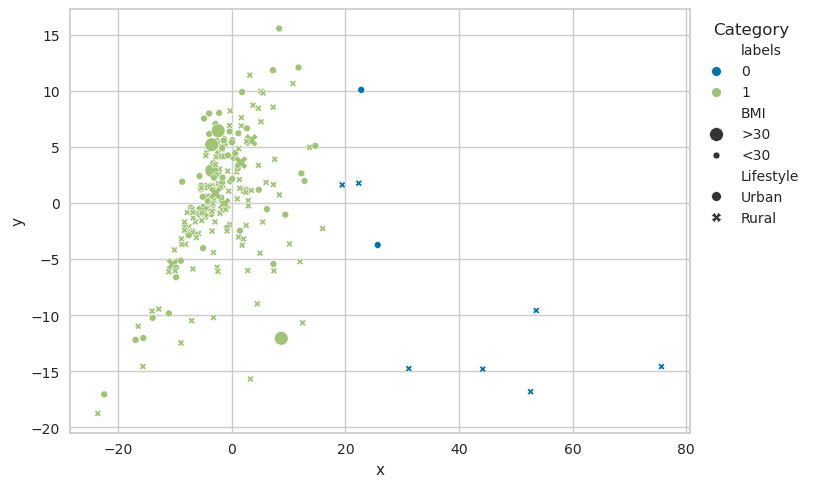

In [300]:
sns.scatterplot(data=components, x='x', y='y', hue= 'labels', style = 'Lifestyle', size = 'BMI', size_order = ['>30', '<30'])
plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))

In [301]:
metadata

,Run,Lane,Sample,Supplier Name,Public Name,Read count,Sample.1,Study,Health state,Disease name,BMI,Antibiotics,Age,Age group,Gender,Lifestyle,Country,Continent
0,37082_3_9,37082_3#9,GI1_LA9438076,50,47,18623506,37082_3_9,Latinbiota,Healthy,NaN,18.1,NaN,7.0,Child,Male,Rural,Mexico,North America
1,37082_3_8,37082_3#8,GI1_LA9438075,49,76,27292796,37082_3_8,Latinbiota,Healthy,NaN,18.7,NaN,9.0,Child,Male,Rural,Mexico,North America
2,37082_3_7,37082_3#7,GI1_LA9438074,47,73,23589062,37082_3_7,Latinbiota,Healthy,NaN,23.5,NaN,23.0,Adult,Female,Rural,Mexico,North America
3,37082_3_6,37082_3#6,GI1_LA9438073,76,161,17556434,37082_3_6,Latinbiota,Healthy,NaN,14.9,NaN,6.0,Child,Male,Rural,Mexico,North America
4,37082_3_5,37082_3#5,GI1_LA9438072,73,159,23119984,37082_3_5,Latinbiota,Healthy,NaN,26.5,NaN,30.0,Adult,Female,Rural,Mexico,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,36703_3_13,36703_3#13,GI1_LA9438059,29,8,21839274,36703_3_13,Latinbiota,Healthy,NaN,23.8,NaN,32.0,Adult,Female,Rural,Mexico,North America
204,36703_3_12,36703_3#12,GI1_LA9438052,22,21,20889370,36703_3_12,Latinbiota,Healthy,NaN,25.6,NaN,10.0,Child,Female,Rural,Mexico,North America
205,36703_3_11,36703_3#11,GI1_LA9438050,B18,B17,21384690,36703_3_11,Latinbiota,Healthy,NaN,17.0,NaN,2.0,Infant,Male,Rural,Mexico,North America
206,36703_3_10,36703_3#10,GI1_LA9438043,C69,C68,21100234,36703_3_10,Latinbiota,Healthy,NaN,15.6,NaN,5.0,Child,Female,Urban,Mexico,North America


In [302]:
metadata['BMI'].describe()

count    170.000000
mean      21.612941
std        6.078155
min        2.100000
25%       16.525000
50%       22.000000
75%       25.375000
max       45.600000
Name: BMI, dtype: float64